# Neural Networks: From Motivation to Practice
### BINF 4002 — Machine Learning for Health — Companion Lab

This notebook accompanies the lecture on neural networks. We'll build intuition by:

1. **Building** a simple MLP from scratch and training it on MNIST
2. **Visualizing** what goes wrong with bad initialization
3. **Comparing** normalization strategies
4. **Exploring** learning rate and batch size interactions
5. **Demonstrating** gradient clipping and accumulation
6. **Monitoring** training with Weights & Biases

**Run in Colab**: Click `Runtime → Run all` or step through cell by cell.

---
## 0. Setup

In [1]:
# Install wandb if needed (Colab)
# (pip install handled by the book's isolated env)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import copy
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/bin/bash: line 1: pip: command not found


Using device: cpu


In [2]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# We'll use a subset for faster experiments
train_subset = torch.utils.data.Subset(train_dataset, range(10000))
test_subset = torch.utils.data.Subset(test_dataset, range(2000))

print(f"Training samples: {len(train_subset)}")
print(f"Test samples: {len(test_subset)}")
print(f"Input shape: {train_dataset[0][0].shape} → flattened to {28*28}")
print(f"Number of classes: 10")

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  7%|▋         | 655k/9.91M [00:00<00:01, 6.50MB/s]

 47%|████▋     | 4.69M/9.91M [00:00<00:00, 25.9MB/s]

 92%|█████████▏| 9.11M/9.91M [00:00<00:00, 33.6MB/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 29.0MB/s]

...

 26%|██▌       | 426k/1.65M [00:00<00:00, 4.07MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 8.72MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 5.13MB/s]

Training samples: 10000
Test samples: 2000
Input shape: torch.Size([1, 28, 28]) → flattened to 784
Number of classes: 10


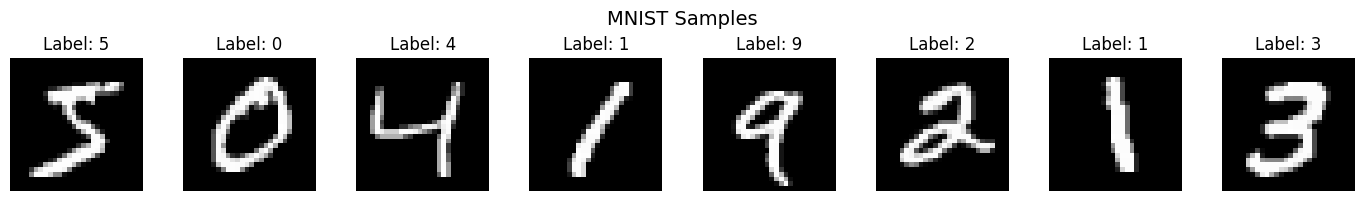

In [3]:
# Visualize a few examples
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()

---
## 1. The Core Building Block: `act(Wx + b)`

Let's build an MLP from first principles before using `nn.Sequential`.

In [4]:
class ManualMLP(nn.Module):
    """MLP written explicitly to show what's happening inside."""

    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10):
        super().__init__()
        # Layer 1: input → hidden
        self.W1 = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(hidden_dim))

        # Layer 2: hidden → hidden
        self.W2 = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(hidden_dim))

        # Layer 3: hidden → output
        self.W3 = nn.Parameter(torch.randn(output_dim, hidden_dim) * 0.01)
        self.b3 = nn.Parameter(torch.zeros(output_dim))

    def forward(self, x):
        # Flatten: (batch, 1, 28, 28) → (batch, 784)
        x = x.view(x.size(0), -1)

        # Layer 1: act(W1 @ x + b1)
        h1 = torch.relu(x @ self.W1.T + self.b1)

        # Layer 2: act(W2 @ h1 + b2)
        h2 = torch.relu(h1 @ self.W2.T + self.b2)

        # Layer 3: W3 @ h2 + b3 (no activation — logits for cross-entropy)
        logits = h2 @ self.W3.T + self.b3

        return logits

# Count parameters
model = ManualMLP()
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")
print(f"  W1: {784}×{256} = {784*256:,}")
print(f"  W2: {256}×{256} = {256*256:,}")
print(f"  W3: {256}×{10}  = {256*10:,}")
print(f"  biases: {256+256+10:,}")

Total parameters: 269,322
  W1: 784×256 = 200,704
  W2: 256×256 = 65,536
  W3: 256×10  = 2,560
  biases: 522


The same thing in idiomatic PyTorch (this is equivalent):

In [5]:
def make_mlp(hidden_dim=256, num_layers=3, use_batchnorm=False, use_layernorm=False,
             use_residual=False, dropout=0.0, activation='relu'):
    """Flexible MLP builder for our experiments."""

    act_fn = {'relu': nn.ReLU, 'gelu': nn.GELU, 'tanh': nn.Tanh, 'sigmoid': nn.Sigmoid}

    class FlexMLP(nn.Module):
        def __init__(self):
            super().__init__()
            layers = []
            dims = [784] + [hidden_dim] * (num_layers - 1) + [10]

            self.blocks = nn.ModuleList()
            self.use_residual = use_residual

            for i in range(len(dims) - 1):
                block = [nn.Linear(dims[i], dims[i+1])]

                if i < len(dims) - 2:  # No activation/norm on last layer
                    if use_batchnorm:
                        block.append(nn.BatchNorm1d(dims[i+1]))
                    if use_layernorm:
                        block.append(nn.LayerNorm(dims[i+1]))
                    block.append(act_fn[activation]())
                    if dropout > 0:
                        block.append(nn.Dropout(dropout))

                self.blocks.append(nn.Sequential(*block))

        def forward(self, x):
            x = x.view(x.size(0), -1)
            for i, block in enumerate(self.blocks):
                if self.use_residual and i > 0 and i < len(self.blocks) - 1:
                    x = x + block(x)  # Residual connection
                else:
                    x = block(x)
            return x

    return FlexMLP()

---
## 2. Training Utilities

Let's write a flexible training loop we can reuse for all experiments.

In [6]:
def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3,
                optimizer_type='adam', weight_decay=0, grad_clip=None,
                accumulation_steps=1, scheduler_type=None, warmup_epochs=0,
                use_wandb=False, run_name=None, verbose=True):
    """
    General training loop with all the bells and whistles.

    Returns: dict with training history
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    if optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    # Scheduler
    scheduler = None
    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_type == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=epochs//3, gamma=0.1)

    history = {
        'train_loss': [], 'test_loss': [],
        'train_acc': [], 'test_acc': [],
        'grad_norms': [], 'learning_rates': []
    }

    if use_wandb:
        import wandb

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        epoch_grad_norms = []

        # Linear warmup
        if epoch < warmup_epochs:
            warmup_lr = lr * (epoch + 1) / warmup_epochs
            for pg in optimizer.param_groups:
                pg['lr'] = warmup_lr

        optimizer.zero_grad()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target) / accumulation_steps
            loss.backward()

            if (batch_idx + 1) % accumulation_steps == 0:
                # Track gradient norms before clipping
                total_norm = 0
                for p in model.parameters():
                    if p.grad is not None:
                        total_norm += p.grad.data.norm(2).item() ** 2
                total_norm = total_norm ** 0.5
                epoch_grad_norms.append(total_norm)

                # Gradient clipping
                if grad_clip is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                optimizer.step()
                optimizer.zero_grad()

            running_loss += loss.item() * accumulation_steps
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        if scheduler is not None and epoch >= warmup_epochs:
            scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # --- Evaluation ---
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                test_loss += criterion(output, target).item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

        test_loss /= len(test_loader)
        test_acc = correct / total
        current_lr = optimizer.param_groups[0]['lr']
        avg_grad_norm = np.mean(epoch_grad_norms) if epoch_grad_norms else 0

        # Record history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['grad_norms'].append(avg_grad_norm)
        history['learning_rates'].append(current_lr)

        if use_wandb:
            wandb.log({
                'train_loss': train_loss, 'test_loss': test_loss,
                'train_acc': train_acc, 'test_acc': test_acc,
                'grad_norm': avg_grad_norm, 'learning_rate': current_lr,
                'epoch': epoch
            })

        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
                  f"Test Loss: {test_loss:.4f} Acc: {test_acc:.3f} | "
                  f"Grad Norm: {avg_grad_norm:.2f} | LR: {current_lr:.2e}")

    return history


def plot_histories(histories, title="Training Comparison"):
    """Plot loss and accuracy curves for multiple experiments."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for name, h in histories.items():
        axes[0].plot(h['train_loss'], label=f'{name} (train)', linestyle='-')
        axes[0].plot(h['test_loss'], label=f'{name} (test)', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves')
    axes[0].legend(fontsize=8)
    axes[0].set_yscale('log')

    for name, h in histories.items():
        axes[1].plot(h['test_acc'], label=name)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title('Test Accuracy')
    axes[1].legend(fontsize=8)

    for name, h in histories.items():
        axes[2].plot(h['grad_norms'], label=name)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Gradient Norm')
    axes[2].set_title('Gradient Norms')
    axes[2].legend(fontsize=8)
    axes[2].set_yscale('log')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 3. Baseline: Train a Standard MLP

Let's first train a well-configured MLP to establish a baseline.

In [7]:
train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False)

print("=" * 60)
print("BASELINE: Standard 3-layer MLP with Kaiming init + Adam")
print("=" * 60)

baseline_model = make_mlp(hidden_dim=256, num_layers=3)

# Apply Kaiming initialization (the PyTorch default for Linear layers is similar)
for m in baseline_model.modules():
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

baseline_history = train_model(
    baseline_model, train_loader, test_loader,
    epochs=25, lr=1e-3, optimizer_type='adam'
)

print(f"\nFinal test accuracy: {baseline_history['test_acc'][-1]:.3f}")

BASELINE: Standard 3-layer MLP with Kaiming init + Adam


Epoch   1/25 | Train Loss: 0.5527 Acc: 0.836 | Test Loss: 0.3515 Acc: 0.886 | Grad Norm: 2.09 | LR: 1.00e-03


Epoch   6/25 | Train Loss: 0.0420 Acc: 0.987 | Test Loss: 0.1859 Acc: 0.943 | Grad Norm: 0.74 | LR: 1.00e-03


Epoch  11/25 | Train Loss: 0.0024 Acc: 1.000 | Test Loss: 0.1914 Acc: 0.946 | Grad Norm: 0.07 | LR: 1.00e-03


Epoch  16/25 | Train Loss: 0.0008 Acc: 1.000 | Test Loss: 0.2037 Acc: 0.949 | Grad Norm: 0.02 | LR: 1.00e-03


Epoch  21/25 | Train Loss: 0.0005 Acc: 1.000 | Test Loss: 0.2082 Acc: 0.949 | Grad Norm: 0.01 | LR: 1.00e-03


Epoch  25/25 | Train Loss: 0.0003 Acc: 1.000 | Test Loss: 0.2138 Acc: 0.949 | Grad Norm: 0.01 | LR: 1.00e-03

Final test accuracy: 0.949


---
## 4. Experiment: Initialization Matters

Let's see what happens with different initialization strategies — including deliberately bad ones.

Training with different initializations...
(This may take a couple minutes)

--- kaiming ---


Epoch   1/20 | Train Loss: 0.4883 Acc: 0.847 | Test Loss: 0.3324 Acc: 0.896 | Grad Norm: 1.93 | LR: 1.00e-03


Epoch   6/20 | Train Loss: 0.0219 Acc: 0.995 | Test Loss: 0.2040 Acc: 0.938 | Grad Norm: 0.45 | LR: 1.00e-03


Epoch  11/20 | Train Loss: 0.0023 Acc: 1.000 | Test Loss: 0.2095 Acc: 0.947 | Grad Norm: 0.07 | LR: 1.00e-03


Epoch  16/20 | Train Loss: 0.0006 Acc: 1.000 | Test Loss: 0.2221 Acc: 0.949 | Grad Norm: 0.02 | LR: 1.00e-03


...

Epoch   1/20 | Train Loss: 2.3022 Acc: 0.106 | Test Loss: 2.3018 Acc: 0.117 | Grad Norm: 0.08 | LR: 1.00e-03


Epoch   6/20 | Train Loss: 2.3007 Acc: 0.113 | Test Loss: 2.3011 Acc: 0.117 | Grad Norm: 0.08 | LR: 1.00e-03


Epoch  11/20 | Train Loss: 2.3002 Acc: 0.113 | Test Loss: 2.3011 Acc: 0.117 | Grad Norm: 0.08 | LR: 1.00e-03


Epoch  16/20 | Train Loss: 2.3006 Acc: 0.113 | Test Loss: 2.3010 Acc: 0.117 | Grad Norm: 0.08 | LR: 1.00e-03


Epoch  20/20 | Train Loss: 2.3006 Acc: 0.113 | Test Loss: 2.3012 Acc: 0.117 | Grad Norm: 0.08 | LR: 1.00e-03



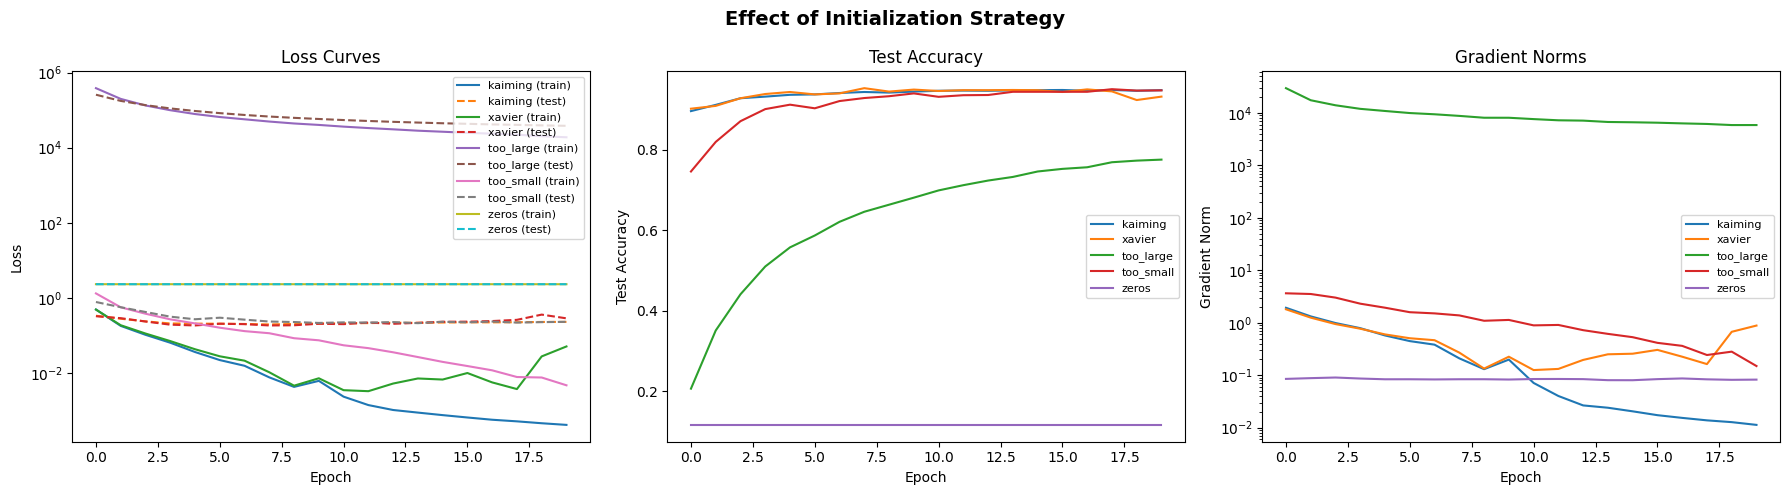

In [8]:
def init_model(model, strategy):
    """Apply different initialization strategies."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == 'kaiming':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif strategy == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif strategy == 'too_large':
                nn.init.normal_(m.weight, mean=0, std=5.0)
            elif strategy == 'too_small':
                nn.init.normal_(m.weight, mean=0, std=0.0001)
            elif strategy == 'zeros':
                nn.init.zeros_(m.weight)
            nn.init.zeros_(m.bias)
    return model

print("Training with different initializations...")
print("(This may take a couple minutes)\n")

init_histories = {}

for strategy in ['kaiming', 'xavier', 'too_large', 'too_small', 'zeros']:
    torch.manual_seed(42)
    model = make_mlp(hidden_dim=256, num_layers=3)
    model = init_model(model, strategy)

    print(f"--- {strategy} ---")
    h = train_model(model, train_loader, test_loader, epochs=20, lr=1e-3, verbose=True)
    init_histories[strategy] = h
    print()

plot_histories(init_histories, "Effect of Initialization Strategy")

### Discussion

- **Kaiming** and **Xavier** both work well; Kaiming is theoretically better for ReLU.
- **Too large** ($\sigma = 5$): Activations explode, gradients are huge initially. May diverge or recover slowly.
- **Too small** ($\sigma = 0.0001$): Activations near zero, gradients tiny. Network barely learns.
- **Zeros**: Complete symmetry — all neurons compute the same function. No learning occurs.

**Takeaway**: Initialization is not a detail you can ignore. Use Kaiming for ReLU networks.

---
## 5. Experiment: Why Depth Is Hard (and How Normalization + Residuals Help)

Let's try training deeper networks and see what breaks.

Training networks of different depths...

--- 3 layers (baseline) (269,322 params) ---


Epoch   1/25 | Train Loss: 0.4883 Acc: 0.847 | Test Loss: 0.3324 Acc: 0.896 | Grad Norm: 1.93 | LR: 1.00e-03


Epoch   6/25 | Train Loss: 0.0219 Acc: 0.995 | Test Loss: 0.2040 Acc: 0.938 | Grad Norm: 0.45 | LR: 1.00e-03


Epoch  11/25 | Train Loss: 0.0023 Acc: 1.000 | Test Loss: 0.2095 Acc: 0.947 | Grad Norm: 0.07 | LR: 1.00e-03


Epoch  16/25 | Train Loss: 0.0006 Acc: 1.000 | Test Loss: 0.2221 Acc: 0.949 | Grad Norm: 0.02 | LR: 1.00e-03


...

Epoch   6/25 | Train Loss: 0.0339 Acc: 0.989 | Test Loss: 0.2554 Acc: 0.931 | Grad Norm: 1.19 | LR: 1.00e-03


Epoch  11/25 | Train Loss: 0.0194 Acc: 0.994 | Test Loss: 0.2489 Acc: 0.941 | Grad Norm: 0.82 | LR: 1.00e-03


Epoch  16/25 | Train Loss: 0.0603 Acc: 0.984 | Test Loss: 0.2963 Acc: 0.931 | Grad Norm: 1.55 | LR: 1.00e-03


Epoch  21/25 | Train Loss: 0.0027 Acc: 0.999 | Test Loss: 0.2618 Acc: 0.945 | Grad Norm: 0.18 | LR: 1.00e-03


Epoch  25/25 | Train Loss: 0.0169 Acc: 0.995 | Test Loss: 0.2951 Acc: 0.939 | Grad Norm: 0.54 | LR: 1.00e-03



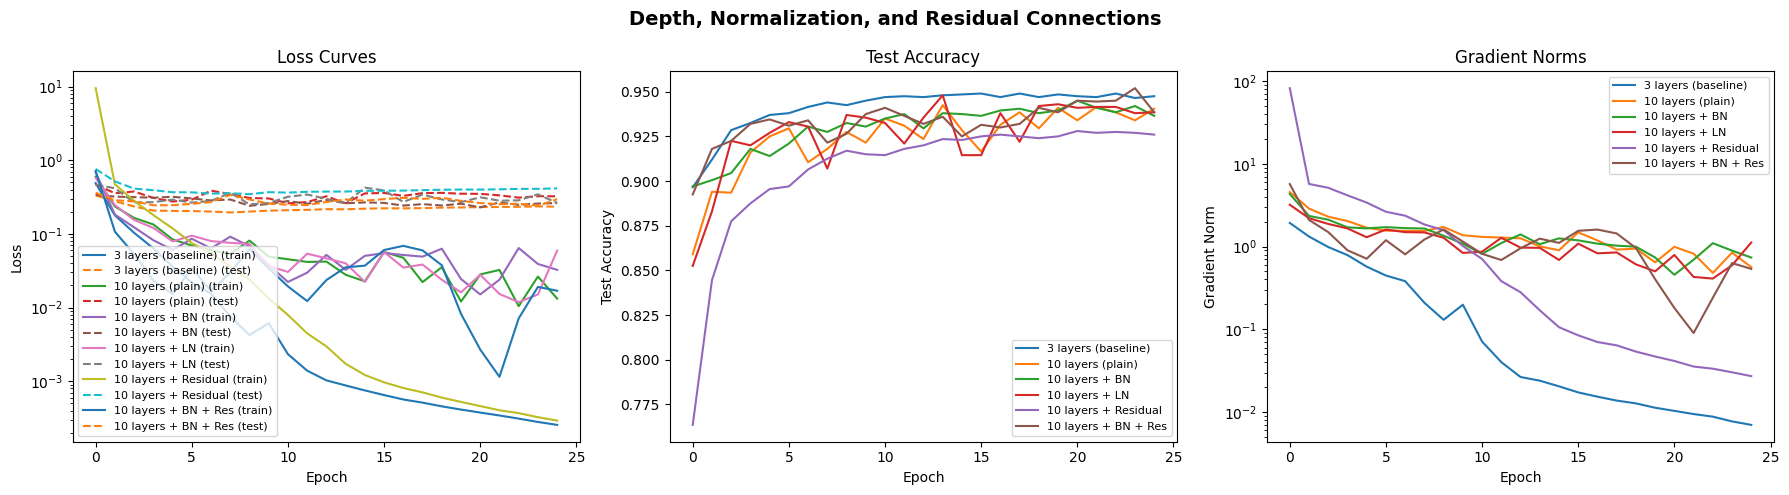

In [9]:
print("Training networks of different depths...\n")

depth_histories = {}

configs = [
    ('3 layers (baseline)',  dict(num_layers=3)),
    ('10 layers (plain)',    dict(num_layers=10)),
    ('10 layers + BN',      dict(num_layers=10, use_batchnorm=True)),
    ('10 layers + LN',      dict(num_layers=10, use_layernorm=True)),
    ('10 layers + Residual', dict(num_layers=10, use_residual=True)),
    ('10 layers + BN + Res', dict(num_layers=10, use_batchnorm=True, use_residual=True)),
]

for name, kwargs in configs:
    torch.manual_seed(42)
    model = make_mlp(hidden_dim=256, **kwargs)
    init_model(model, 'kaiming')

    print(f"--- {name} ({sum(p.numel() for p in model.parameters()):,} params) ---")
    h = train_model(model, train_loader, test_loader, epochs=25, lr=1e-3)
    depth_histories[name] = h
    print()

plot_histories(depth_histories, "Depth, Normalization, and Residual Connections")

### Discussion

- A plain 10-layer network often trains **worse** than a 3-layer one (the degradation problem).
- **Batch/LayerNorm** stabilize training by keeping activations well-scaled.
- **Residual connections** let gradients flow and make depth useful.
- **BN + Residual** together is typically the winning combination for deep MLPs.

This is exactly the insight behind ResNet, which made 100+ layer training practical.

---
## 6. Experiment: Learning Rate — The Most Important Hyperparameter

Training with different learning rates...

--- LR = 0.1 ---


Epoch   1/20 | Train Loss: 27.7411 Acc: 0.181 | Test Loss: 2.1673 Acc: 0.163 | Grad Norm: 42.79 | LR: 1.00e-01


Epoch   6/20 | Train Loss: 2.1052 Acc: 0.180 | Test Loss: 2.0503 Acc: 0.188 | Grad Norm: 0.19 | LR: 1.00e-01


Epoch  11/20 | Train Loss: 1.9945 Acc: 0.210 | Test Loss: 2.0025 Acc: 0.218 | Grad Norm: 0.16 | LR: 1.00e-01


Epoch  16/20 | Train Loss: 1.9817 Acc: 0.206 | Test Loss: 1.9853 Acc: 0.215 | Grad Norm: 0.15 | LR: 1.00e-01


...

Epoch   1/20 | Train Loss: 2.5071 Acc: 0.148 | Test Loss: 2.2083 Acc: 0.213 | Grad Norm: 5.20 | LR: 1.00e-05


Epoch   6/20 | Train Loss: 1.0215 Acc: 0.725 | Test Loss: 1.1227 Acc: 0.673 | Grad Norm: 2.51 | LR: 1.00e-05


Epoch  11/20 | Train Loss: 0.6062 Acc: 0.841 | Test Loss: 0.7467 Acc: 0.792 | Grad Norm: 1.97 | LR: 1.00e-05


Epoch  16/20 | Train Loss: 0.4411 Acc: 0.883 | Test Loss: 0.5840 Acc: 0.845 | Grad Norm: 1.78 | LR: 1.00e-05


Epoch  20/20 | Train Loss: 0.3705 Acc: 0.902 | Test Loss: 0.5114 Acc: 0.860 | Grad Norm: 1.70 | LR: 1.00e-05



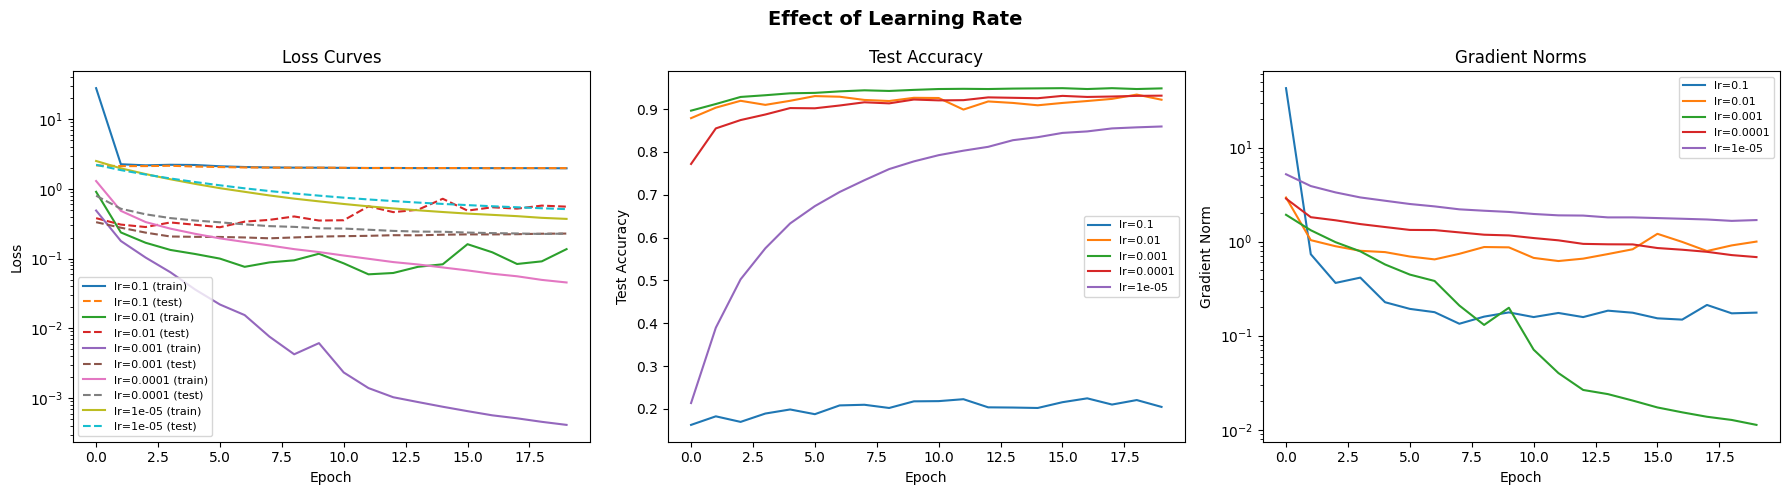

In [10]:
print("Training with different learning rates...\n")

lr_histories = {}

for lr in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    torch.manual_seed(42)
    model = make_mlp(hidden_dim=256, num_layers=3)
    init_model(model, 'kaiming')

    print(f"--- LR = {lr} ---")
    h = train_model(model, train_loader, test_loader, epochs=20, lr=lr)
    lr_histories[f'lr={lr}'] = h
    print()

plot_histories(lr_histories, "Effect of Learning Rate")

### Discussion

- **Too high** (0.1): Loss may diverge or oscillate wildly.
- **Just right** (1e-3): Smooth convergence.
- **Too low** (1e-5): Training proceeds but painfully slowly.

In practice, you often sweep LR on a log scale (e.g., {1e-4, 3e-4, 1e-3, 3e-3, 1e-2}) as your first hyperparameter search.

---
## 7. Experiment: LR Schedules and Warmup

Comparing LR schedules...

--- constant ---


Epoch   1/30 | Train Loss: 0.4883 Acc: 0.847 | Test Loss: 0.3324 Acc: 0.896 | Grad Norm: 1.93 | LR: 1.00e-03


Epoch   6/30 | Train Loss: 0.0219 Acc: 0.995 | Test Loss: 0.2040 Acc: 0.938 | Grad Norm: 0.45 | LR: 1.00e-03


Epoch  11/30 | Train Loss: 0.0023 Acc: 1.000 | Test Loss: 0.2095 Acc: 0.947 | Grad Norm: 0.07 | LR: 1.00e-03


Epoch  16/30 | Train Loss: 0.0006 Acc: 1.000 | Test Loss: 0.2221 Acc: 0.949 | Grad Norm: 0.02 | LR: 1.00e-03


...

Epoch  11/30 | Train Loss: 0.0360 Acc: 0.987 | Test Loss: 0.3148 Acc: 0.946 | Grad Norm: 0.55 | LR: 4.17e-03


Epoch  16/30 | Train Loss: 0.0048 Acc: 0.999 | Test Loss: 0.3179 Acc: 0.948 | Grad Norm: 0.13 | LR: 3.02e-03


Epoch  21/30 | Train Loss: 0.0001 Acc: 1.000 | Test Loss: 0.3189 Acc: 0.948 | Grad Norm: 0.00 | LR: 1.73e-03


Epoch  26/30 | Train Loss: 0.0001 Acc: 1.000 | Test Loss: 0.3212 Acc: 0.949 | Grad Norm: 0.00 | LR: 6.42e-04


Epoch  30/30 | Train Loss: 0.0000 Acc: 1.000 | Test Loss: 0.3219 Acc: 0.948 | Grad Norm: 0.00 | LR: 1.22e-04



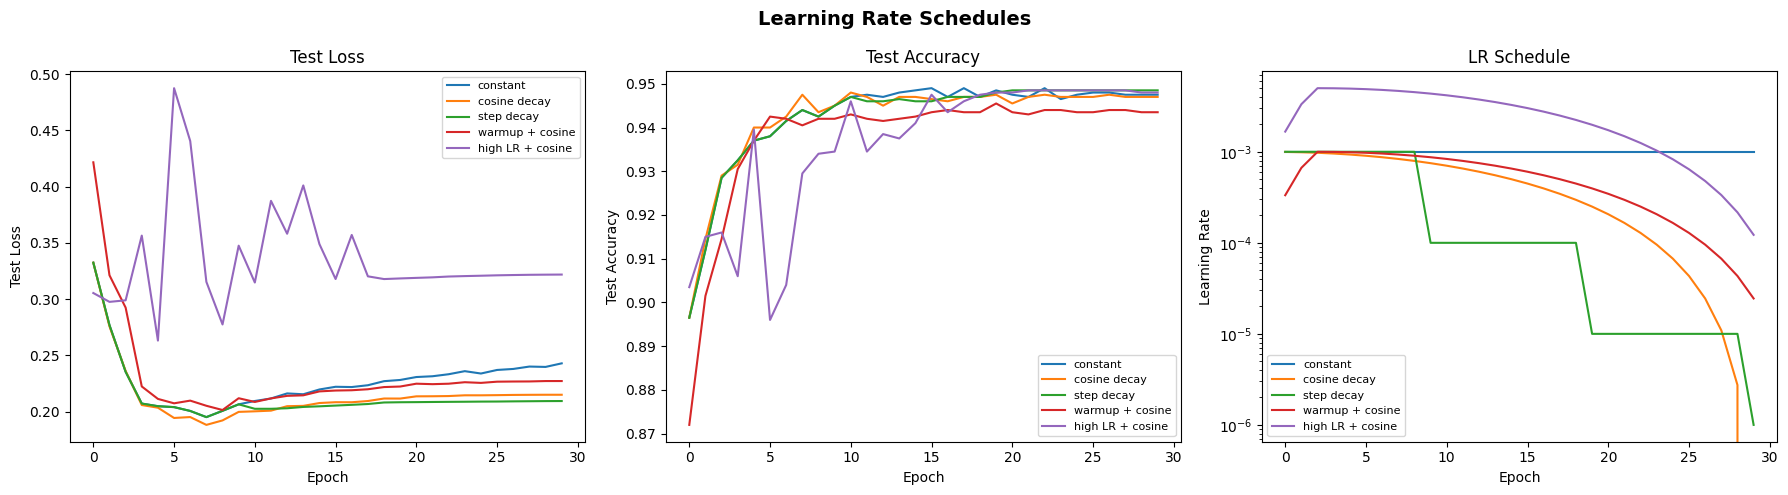

In [11]:
print("Comparing LR schedules...\n")

schedule_histories = {}

configs = [
    ('constant',         dict(lr=1e-3)),
    ('cosine decay',     dict(lr=1e-3, scheduler_type='cosine')),
    ('step decay',       dict(lr=1e-3, scheduler_type='step')),
    ('warmup + cosine',  dict(lr=1e-3, scheduler_type='cosine', warmup_epochs=3)),
    ('high LR + cosine', dict(lr=5e-3, scheduler_type='cosine', warmup_epochs=3)),
]

for name, kwargs in configs:
    torch.manual_seed(42)
    model = make_mlp(hidden_dim=256, num_layers=3)
    init_model(model, 'kaiming')

    print(f"--- {name} ---")
    h = train_model(model, train_loader, test_loader, epochs=30, **kwargs)
    schedule_histories[name] = h
    print()

# Plot including LR schedule
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, h in schedule_histories.items():
    axes[0].plot(h['test_loss'], label=name)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Loss')
axes[0].set_title('Test Loss')
axes[0].legend(fontsize=8)

for name, h in schedule_histories.items():
    axes[1].plot(h['test_acc'], label=name)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy')
axes[1].legend(fontsize=8)

for name, h in schedule_histories.items():
    axes[2].plot(h['learning_rates'], label=name)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule')
axes[2].legend(fontsize=8)
axes[2].set_yscale('log')

plt.suptitle("Learning Rate Schedules", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Experiment: Batch Size and the LR—Batch Size Relationship

Batch size experiments...

The linear scaling rule says: when you multiply batch size by k, multiply LR by k.

NOTE: We use SGD here — adaptive optimizers (Adam) mask the effect.

--- bs=64, lr=0.01 ---


Epoch   1/20 | Train Loss: 0.4688 Acc: 0.854 | Test Loss: 0.3172 Acc: 0.904 | Grad Norm: 2.24 | LR: 1.00e-02


Epoch   6/20 | Train Loss: 0.0246 Acc: 0.996 | Test Loss: 0.2086 Acc: 0.939 | Grad Norm: 0.58 | LR: 1.00e-02


Epoch  11/20 | Train Loss: 0.0047 Acc: 1.000 | Test Loss: 0.2149 Acc: 0.943 | Grad Norm: 0.14 | LR: 1.00e-02


Epoch  16/20 | Train Loss: 0.0024 Acc: 1.000 | Test Loss: 0.2218 Acc: 0.944 | Grad Norm: 0.08 | LR: 1.00e-02


...

Epoch   1/20 | Train Loss: 0.4122 Acc: 0.874 | Test Loss: 0.3213 Acc: 0.900 | Grad Norm: 4.03 | LR: 2.50e-03


Epoch   6/20 | Train Loss: 0.0236 Acc: 0.996 | Test Loss: 0.2122 Acc: 0.938 | Grad Norm: 0.91 | LR: 2.50e-03


Epoch  11/20 | Train Loss: 0.0043 Acc: 1.000 | Test Loss: 0.2180 Acc: 0.939 | Grad Norm: 0.22 | LR: 2.50e-03


Epoch  16/20 | Train Loss: 0.0023 Acc: 1.000 | Test Loss: 0.2272 Acc: 0.940 | Grad Norm: 0.13 | LR: 2.50e-03


Epoch  20/20 | Train Loss: 0.0016 Acc: 1.000 | Test Loss: 0.2321 Acc: 0.938 | Grad Norm: 0.09 | LR: 2.50e-03



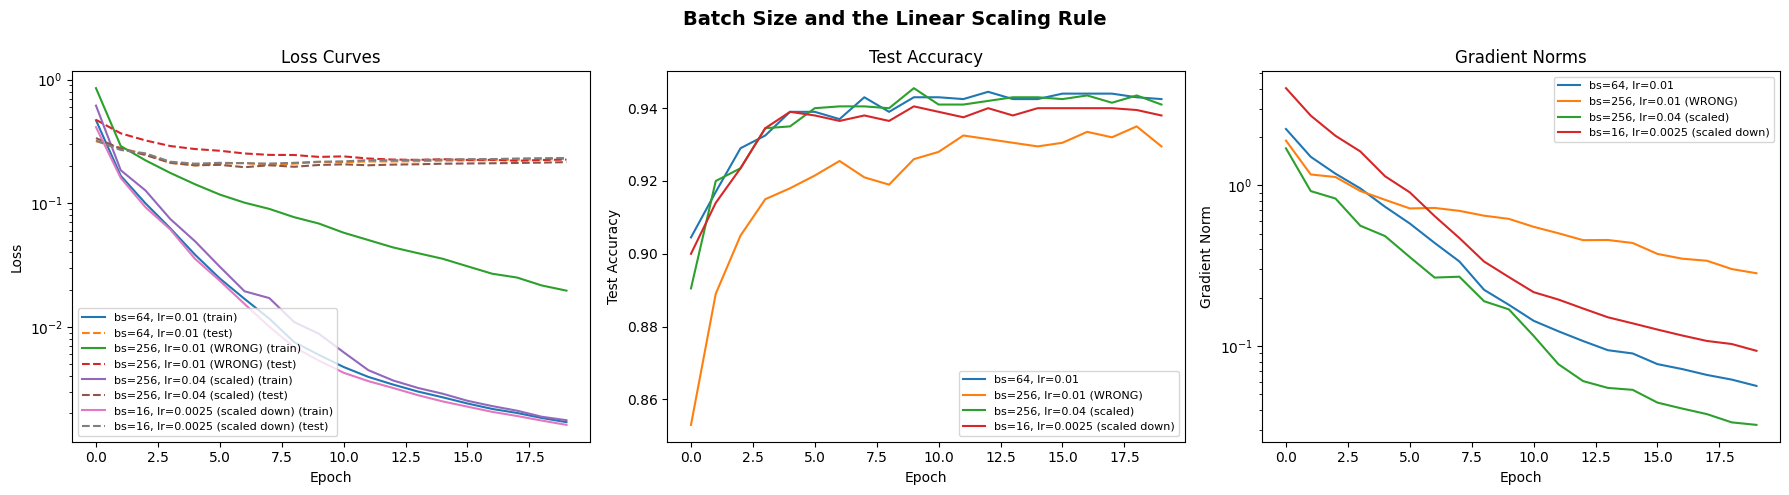

In [12]:
print("Batch size experiments...\n")
print("The linear scaling rule says: when you multiply batch size by k, multiply LR by k.\n")
print("NOTE: We use SGD here — adaptive optimizers (Adam) mask the effect.\n")

bs_histories = {}

base_lr = 1e-2
base_bs = 64

configs = [
    (f'bs={base_bs}, lr={base_lr}', base_bs, base_lr),
    (f'bs={base_bs*4}, lr={base_lr} (WRONG)', base_bs * 4, base_lr),
    (f'bs={base_bs*4}, lr={base_lr*4} (scaled)', base_bs * 4, base_lr * 4),
    (f'bs=16, lr={base_lr/4} (scaled down)', 16, base_lr / 4),
]

for name, bs, lr in configs:
    torch.manual_seed(42)
    model = make_mlp(hidden_dim=256, num_layers=3)
    init_model(model, 'kaiming')

    loader = DataLoader(train_subset, batch_size=bs, shuffle=True)

    print(f"--- {name} ---")
    h = train_model(model, loader, test_loader, epochs=20, lr=lr, optimizer_type='sgd')
    bs_histories[name] = h
    print()

plot_histories(bs_histories, "Batch Size and the Linear Scaling Rule")

### Discussion

- Increasing batch size **without** scaling LR → effectively lower LR per data point → slower training.
- The **linear scaling rule** corrects for this: multiply LR proportionally with batch size.
- Very large batch sizes eventually break the linear scaling rule and need more careful treatment (e.g., LARS/LAMB optimizers, extended warmup).

---
## 9. Experiment: Gradient Clipping in Action

Demonstrating gradient clipping...
We'll use a deliberately unstable setup (high LR, deep network, no normalization)

--- no clipping ---


Epoch   1/20 | Train Loss: 0.8049 Acc: 0.774 | Test Loss: 0.4081 Acc: 0.872 | Grad Norm: 2.90 | LR: 5.00e-03


Epoch   6/20 | Train Loss: 0.0978 Acc: 0.971 | Test Loss: 0.3136 Acc: 0.915 | Grad Norm: 0.88 | LR: 5.00e-03


Epoch  11/20 | Train Loss: 0.0602 Acc: 0.982 | Test Loss: 0.3170 Acc: 0.939 | Grad Norm: 0.68 | LR: 5.00e-03


Epoch  16/20 | Train Loss: 0.0559 Acc: 0.984 | Test Loss: 0.3369 Acc: 0.936 | Grad Norm: 0.68 | LR: 5.00e-03


...

Epoch   1/20 | Train Loss: 0.7748 Acc: 0.789 | Test Loss: 0.4296 Acc: 0.865 | Grad Norm: 2.79 | LR: 5.00e-03


Epoch   6/20 | Train Loss: 0.1181 Acc: 0.968 | Test Loss: 0.4945 Acc: 0.907 | Grad Norm: 0.86 | LR: 5.00e-03


Epoch  11/20 | Train Loss: 0.0855 Acc: 0.981 | Test Loss: 0.4708 Acc: 0.928 | Grad Norm: 0.80 | LR: 5.00e-03


Epoch  16/20 | Train Loss: 0.0727 Acc: 0.985 | Test Loss: 0.7825 Acc: 0.926 | Grad Norm: 0.79 | LR: 5.00e-03


Epoch  20/20 | Train Loss: 0.0756 Acc: 0.987 | Test Loss: 0.6202 Acc: 0.917 | Grad Norm: 0.79 | LR: 5.00e-03



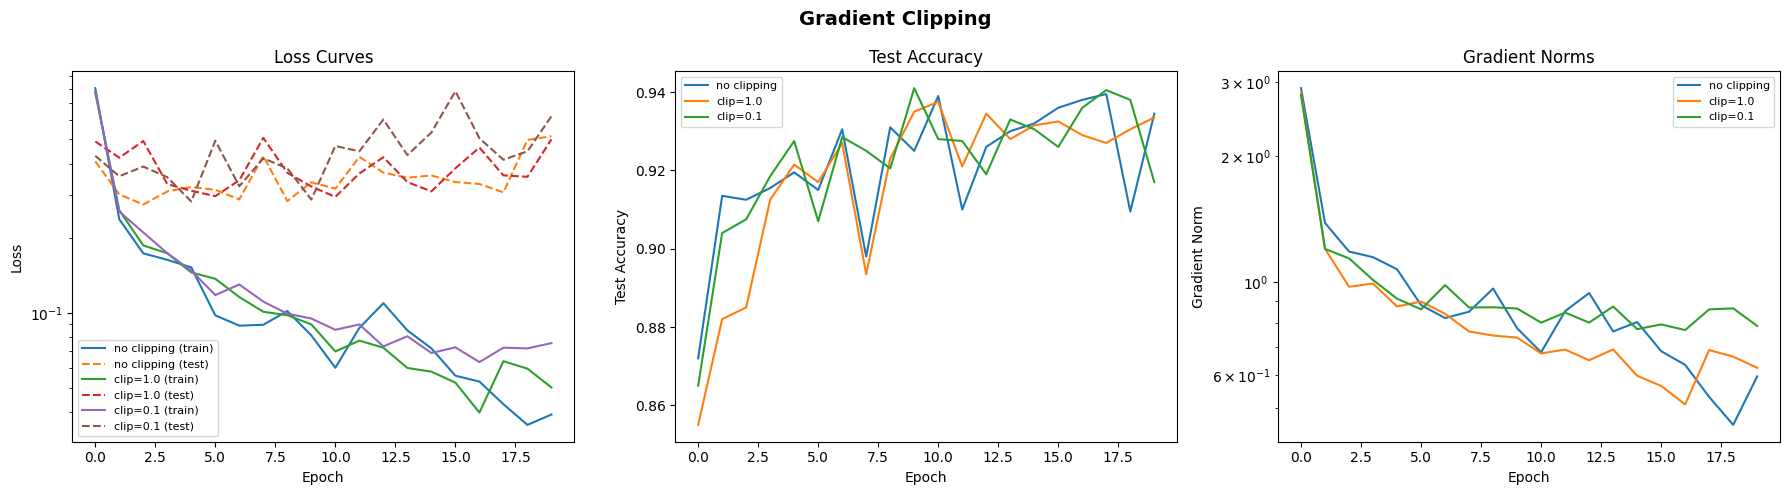

In [13]:
print("Demonstrating gradient clipping...")
print("We'll use a deliberately unstable setup (high LR, deep network, no normalization)\n")

clip_histories = {}

for clip_val, label in [(None, 'no clipping'), (1.0, 'clip=1.0'), (0.1, 'clip=0.1')]:
    torch.manual_seed(42)
    # Deliberately challenging: deep, no norm, somewhat high LR
    model = make_mlp(hidden_dim=256, num_layers=6)
    init_model(model, 'kaiming')

    print(f"--- {label} ---")
    h = train_model(
        model, train_loader, test_loader,
        epochs=20, lr=5e-3, grad_clip=clip_val
    )
    clip_histories[label] = h
    print()

plot_histories(clip_histories, "Gradient Clipping")

### Discussion

- Without clipping, a deep network with high LR can see gradient spikes that blow up training.
- Gradient clipping acts as a **safety net**: it doesn't change the gradient direction, just bounds its magnitude.
- Typical clip value: 1.0. If you need very aggressive clipping (0.01), something else is probably wrong.

---
## 10. Experiment: Gradient Accumulation

Gradient accumulation: simulating a larger batch size

Effective batch size = micro_batch_size × accumulation_steps

--- bs=256 (actual) ---


Epoch   1/20 | Train Loss: 0.6156 Acc: 0.807 | Test Loss: 0.3362 Acc: 0.890 | Grad Norm: 1.70 | LR: 4.00e-02


Epoch   6/20 | Train Loss: 0.0307 Acc: 0.994 | Test Loss: 0.2043 Acc: 0.940 | Grad Norm: 0.36 | LR: 4.00e-02


Epoch  11/20 | Train Loss: 0.0062 Acc: 1.000 | Test Loss: 0.2063 Acc: 0.941 | Grad Norm: 0.12 | LR: 4.00e-02


Epoch  16/20 | Train Loss: 0.0025 Acc: 1.000 | Test Loss: 0.2097 Acc: 0.943 | Grad Norm: 0.04 | LR: 4.00e-02


...

Epoch   1/20 | Train Loss: 0.4688 Acc: 0.854 | Test Loss: 0.3172 Acc: 0.904 | Grad Norm: 2.24 | LR: 1.00e-02


Epoch   6/20 | Train Loss: 0.0246 Acc: 0.996 | Test Loss: 0.2086 Acc: 0.939 | Grad Norm: 0.58 | LR: 1.00e-02


Epoch  11/20 | Train Loss: 0.0047 Acc: 1.000 | Test Loss: 0.2149 Acc: 0.943 | Grad Norm: 0.14 | LR: 1.00e-02


Epoch  16/20 | Train Loss: 0.0024 Acc: 1.000 | Test Loss: 0.2218 Acc: 0.944 | Grad Norm: 0.08 | LR: 1.00e-02


Epoch  20/20 | Train Loss: 0.0017 Acc: 1.000 | Test Loss: 0.2277 Acc: 0.943 | Grad Norm: 0.06 | LR: 1.00e-02



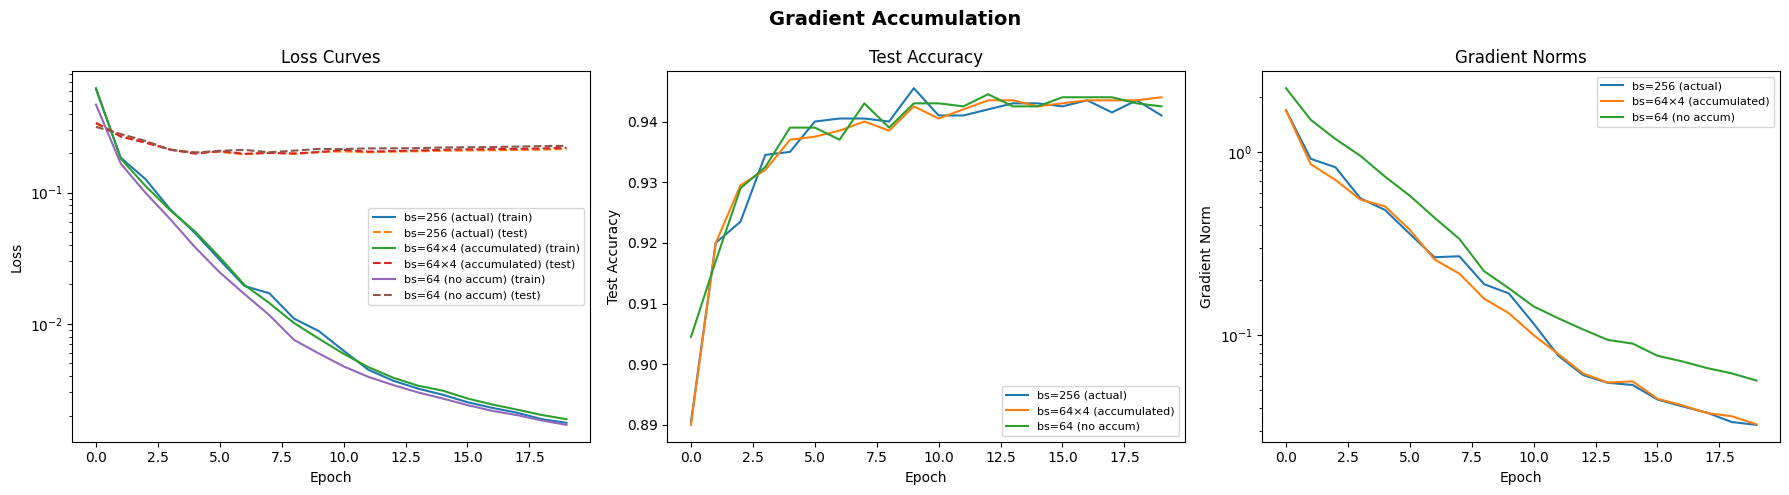

In [14]:
print("Gradient accumulation: simulating a larger batch size\n")
print("Effective batch size = micro_batch_size × accumulation_steps\n")

accum_histories = {}

# Baseline: batch size 256 with scaled LR
torch.manual_seed(42)
model = make_mlp(hidden_dim=256, num_layers=3)
init_model(model, 'kaiming')
loader_256 = DataLoader(train_subset, batch_size=256, shuffle=True)
print("--- bs=256 (actual) ---")
h = train_model(model, loader_256, test_loader, epochs=20, lr=4e-2, optimizer_type='sgd')
accum_histories['bs=256 (actual)'] = h
print()

# Simulated: batch size 64 × 4 accumulation steps = effective 256
torch.manual_seed(42)
model = make_mlp(hidden_dim=256, num_layers=3)
init_model(model, 'kaiming')
loader_64 = DataLoader(train_subset, batch_size=64, shuffle=True)
print("--- bs=64 × 4 accum = 256 (simulated) ---")
h = train_model(model, loader_64, test_loader, epochs=20, lr=4e-2, optimizer_type='sgd', accumulation_steps=4)
accum_histories['bs=64×4 (accumulated)'] = h
print()

# For comparison: actual batch size 64
torch.manual_seed(42)
model = make_mlp(hidden_dim=256, num_layers=3)
init_model(model, 'kaiming')
print("--- bs=64 (no accumulation) ---")
h = train_model(model, loader_64, test_loader, epochs=20, lr=1e-2, optimizer_type='sgd')
accum_histories['bs=64 (no accum)'] = h
print()

plot_histories(accum_histories, "Gradient Accumulation")

### Discussion

Gradient accumulation lets you simulate large batch sizes when your GPU can't fit them. The accumulated version should closely match the actual large-batch training (up to differences in batch normalization statistics, if used).

This is essential when:
- You're fine-tuning large models on limited hardware
- Your data samples are large (e.g., high-res images, long sequences)
- You want to scale up without changing hardware

---
## 11. Monitoring with Weights & Biases

Everything above was tracked locally. In real projects, you'll want a centralized dashboard.
[Weights & Biases (wandb)](https://wandb.ai) is the most popular option.

In [15]:
# Uncomment and run this cell to try wandb integration
# You'll need a free wandb account: https://wandb.ai/authorize

USE_WANDB = False  # Set to True to enable

if USE_WANDB:
    import wandb

    # Log in (will prompt for API key in Colab)
    wandb.login()

    # Start a run
    wandb.init(
        project="binf4002-nn-lab",
        name="demo-run",
        config={
            "architecture": "MLP",
            "hidden_dim": 256,
            "num_layers": 3,
            "learning_rate": 1e-3,
            "batch_size": 128,
            "optimizer": "adam",
            "dataset": "MNIST",
        }
    )

    torch.manual_seed(42)
    model = make_mlp(hidden_dim=256, num_layers=3)
    init_model(model, 'kaiming')

    h = train_model(
        model, train_loader, test_loader,
        epochs=20, lr=1e-3, use_wandb=True,
        run_name='demo-run'
    )

    # Log final model
    wandb.finish()
    print("\n✅ Check your wandb dashboard for interactive plots!")
else:
    print("Set USE_WANDB = True above to try Weights & Biases integration.")
    print("\nWhat you would see in the wandb dashboard:")
    print("  • Interactive loss/accuracy curves")
    print("  • Gradient norm tracking")
    print("  • LR schedule visualization")
    print("  • System metrics (GPU util, memory)")
    print("  • Side-by-side comparison of runs")
    print("  • Hyperparameter search visualization")

Set USE_WANDB = True above to try Weights & Biases integration.

What you would see in the wandb dashboard:
  • Interactive loss/accuracy curves
  • Gradient norm tracking
  • LR schedule visualization
  • System metrics (GPU util, memory)
  • Side-by-side comparison of runs
  • Hyperparameter search visualization


---
## 12. Visualizing What the Network Learns

Let's peek inside our trained network.

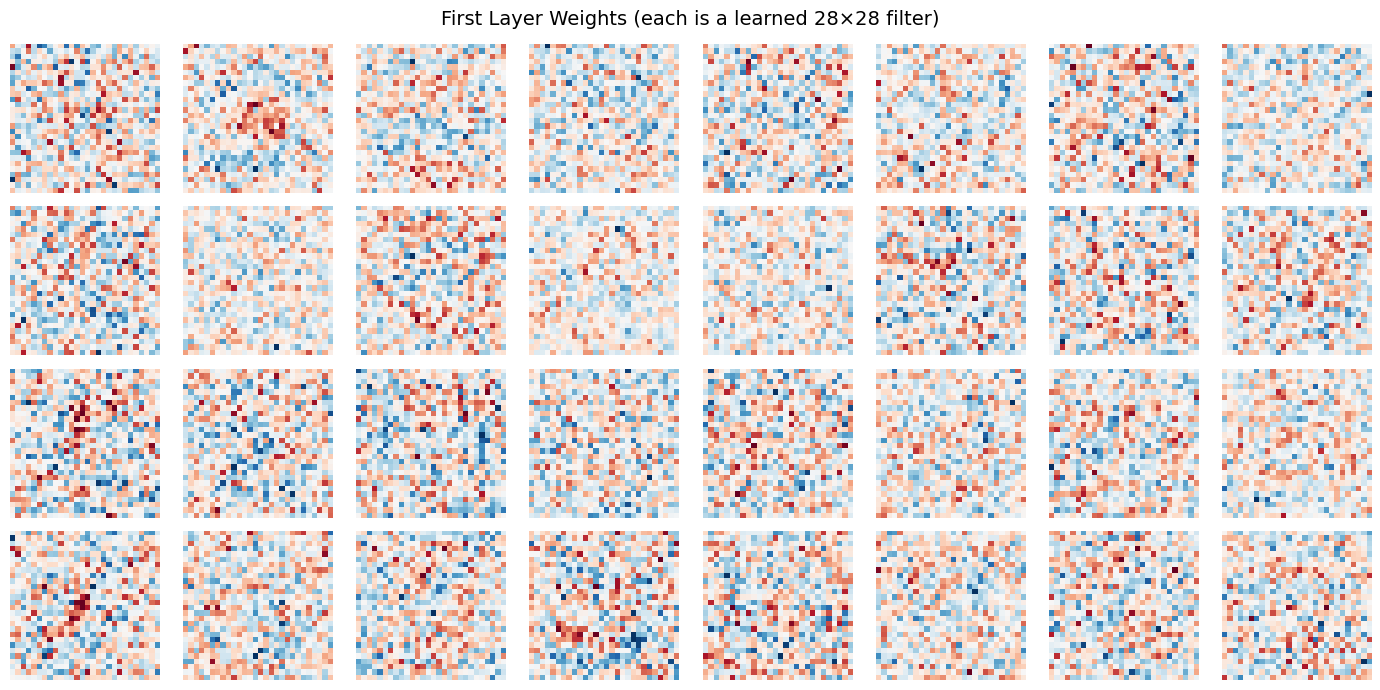

In [16]:
# Use the baseline model we trained earlier
baseline_model.eval()

# Visualize first-layer weights as 28×28 images
# Each row of W1 is a 784-dim vector that can be reshaped to 28×28
first_layer = list(baseline_model.blocks[0].parameters())[0] # First weight matrix
weights = first_layer.detach().cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        w = weights[i].reshape(28, 28)
        ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
    ax.axis('off')
plt.suptitle("First Layer Weights (each is a learned 28×28 filter)", fontsize=14)
plt.tight_layout()
plt.show()

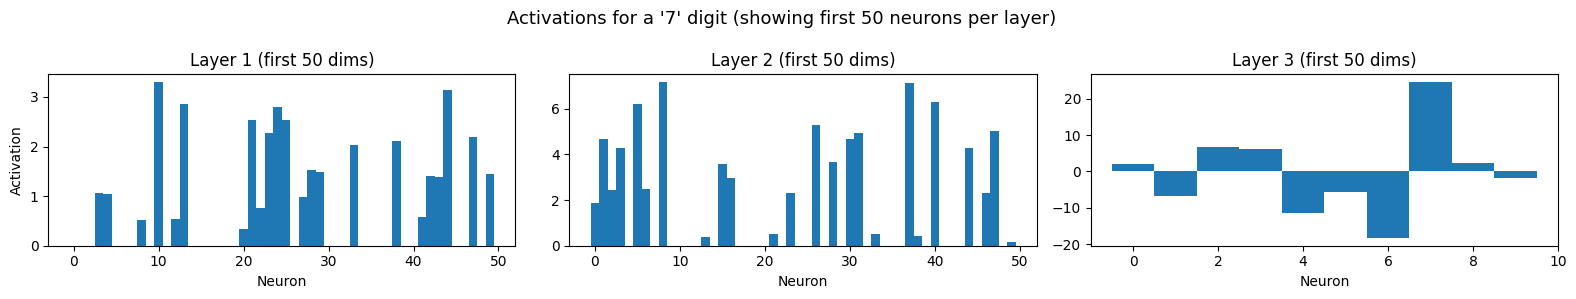

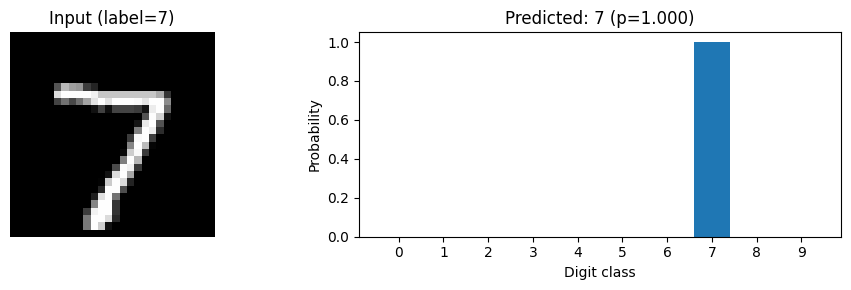

In [17]:
# Visualize activations for a single input
baseline_model.eval()
sample_img, sample_label = test_dataset[0]
x = sample_img.unsqueeze(0).to(device)

# Forward pass, capturing intermediates
activations = []
h = x.view(1, -1)
for block in baseline_model.blocks:
    h = block(h)
    activations.append(h.detach().cpu().numpy().flatten())

fig, axes = plt.subplots(1, len(activations), figsize=(16, 3))
for i, (act, ax) in enumerate(zip(activations, axes)):
    ax.bar(range(len(act[:50])), act[:50], width=1.0)  # Show first 50 dims
    ax.set_title(f"Layer {i+1} (first 50 dims)")
    ax.set_xlabel("Neuron")
    if i == 0:
        ax.set_ylabel("Activation")

plt.suptitle(f"Activations for a '{sample_label}' digit (showing first 50 neurons per layer)", fontsize=13)
plt.tight_layout()
plt.show()

# Show the prediction
with torch.no_grad():
    logits = baseline_model(sample_img.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy().flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.imshow(sample_img.squeeze(), cmap='gray')
ax1.set_title(f"Input (label={sample_label})")
ax1.axis('off')

ax2.bar(range(10), probs)
ax2.set_xlabel('Digit class')
ax2.set_ylabel('Probability')
ax2.set_title(f'Predicted: {probs.argmax()} (p={probs.max():.3f})')
ax2.set_xticks(range(10))
plt.tight_layout()
plt.show()

---
## 13. Summary: What We've Learned

| Concept | Key Takeaway |
|---------|-------------|
| **Layers** | `act(Wx + b)` — the fundamental building block |
| **Initialization** | Use Kaiming for ReLU; bad init → no learning |
| **Normalization** | BatchNorm/LayerNorm stabilize deep training |
| **Residual connections** | Essential for training deep networks |
| **Learning rate** | Most important hyperparameter; sweep on log scale |
| **LR schedules** | Warmup + cosine decay is a strong default |
| **Batch size ↔ LR** | Linear scaling rule: scale LR with batch size |
| **Gradient clipping** | Safety net for unstable training |
| **Gradient accumulation** | Simulate large batches on small GPUs |
| **Monitoring** | Track loss, accuracy, grad norms, LR with wandb |

### Next Steps

Try modifying these experiments:
- Change the activation function (GELU, tanh, sigmoid) — what changes?
- Add dropout and compare generalization (train-test gap)
- Try SGD with momentum instead of Adam
- Increase to the full MNIST dataset (60K training samples)
- Replace the MLP with a simple CNN and compare

In [18]:
print("🎉 Lab complete! See the lecture slides for the conceptual framework behind everything here.")

🎉 Lab complete! See the lecture slides for the conceptual framework behind everything here.
